This code estimates the charging rate from the full charging cycle and then uses the small tests as validation

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

F = 96485.3329
z = 2
Vm = 24000

DATA_DIR = Path("../../data/PEM_test/charge_discharge")
READINGS_PATH = Path("../../data/PEM_test/volume_readings/readings.csv")

FULL_CHARGE_FILE = "discharge_PEM_full.csv"
FULL_CHARGE_VOLUME_ML = 15.6

CURRENT_CORRECTION = {
    0x44: lambda i: i + 0.000138,
    0x45: lambda i: 0.843 * i + 0.001,
}

VOLTAGE_CORRECTION = {
    0x44: lambda v: v - 0.180,
    0x45: lambda v: v - 0.064,
}

In [3]:
charge_test_files = [
    "discharge_020A_30s_r1.csv",
    "discharge_020A_60s_r1.csv",
    "discharge_020A_120s_r1.csv",
    "discharge_030A_30s_r1.csv",
    "discharge_030A_60s_r1.csv",
    "discharge_030A_120s_r1.csv",
    "discharge_040A_30s_r1.csv",
    "discharge_040A_60s_r1.csv",
    "discharge_040A_120s_r1.csv",
]

readings = pd.read_csv(READINGS_PATH)

readings["current_A"] = readings["current_A"].astype(float)
readings["time_s"] = readings["time_s"].astype(float)
readings["volume_mL"] = readings["volume_mL"].astype(float)

print(readings)

   current_A  time_s  volume_mL
0        0.2    30.0        0.2
1        0.2    60.0        1.6
2        0.2   120.0        3.0
3        0.3    30.0        1.6
4        0.3    60.0        2.2
5        0.3   120.0        4.2
6        0.4    30.0        2.2
7        0.4    60.0        4.0
8        0.4   120.0        6.0


In [4]:
def parse_charge_test_name(file_name):
    parts = file_name.replace(".csv", "").split("_")
    current_A = int(parts[1].replace("A", "")) / 100
    time_s = int(parts[2].replace("s", ""))
    return current_A, time_s


def load_and_correct_file(file_name):
    path = DATA_DIR / file_name
    
    df = pd.read_csv(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp").reset_index(drop=True)
    
    df["time_s"] = (
        df["timestamp"] - df["timestamp"].iloc[0]
    ).dt.total_seconds()
    
    df["dt_s"] = df["timestamp"].diff().dt.total_seconds().fillna(0)
    
    df["dc_current_A"] = CURRENT_CORRECTION[0x44](
        df["ina3_current_mA"] / 1000
    )
    
    df["dc_voltage_V"] = VOLTAGE_CORRECTION[0x44](
        df["ina3_bus_V"]
    )
    
    df["pem_current_A"] = CURRENT_CORRECTION[0x45](
        df["ina4_current_mA"] / 1000
    )
    
    df["pem_voltage_V"] = VOLTAGE_CORRECTION[0x45](
        df["ina4_bus_V"]
    )
    
    df["pem_power_W"] = (
        df["pem_voltage_V"]
        * df["pem_current_A"]
    )
    
    return df


def extract_charge_part(
    df,
    expected_time_s=None,
    power_threshold_W=0.02,
    drop_fraction=0.5
):
    charge = df[df["scenario"] == 3].copy()
    charge = charge.sort_values("timestamp").reset_index(drop=True)
    
    active = charge["pem_power_W"] > power_threshold_W
    
    if not active.any():
        return charge.iloc[0:0].copy()
    
    start_idx = active.idxmax()
    charge = charge.loc[start_idx:].copy().reset_index(drop=True)
    
    steady_power = charge["pem_power_W"].max()
    collapse_threshold = drop_fraction * steady_power
    
    collapse = charge["pem_power_W"] < collapse_threshold
    collapse.iloc[:5] = False
    
    if collapse.any():
        end_idx = collapse.idxmax()
        charge = charge.loc[:end_idx - 1].copy()
    
    if expected_time_s is not None:
        start_time = charge["time_s"].iloc[0]
        end_time = start_time + expected_time_s
        
        charge = charge[
            (charge["time_s"] >= start_time)
            & (charge["time_s"] <= end_time)
        ].copy()
    
    charge = charge.reset_index(drop=True)
    
    charge["dt_s"] = (
        charge["timestamp"]
        .diff()
        .dt.total_seconds()
        .fillna(0)
    )
    
    charge["time_charge_s"] = (
        charge["timestamp"] - charge["timestamp"].iloc[0]
    ).dt.total_seconds()
    
    return charge

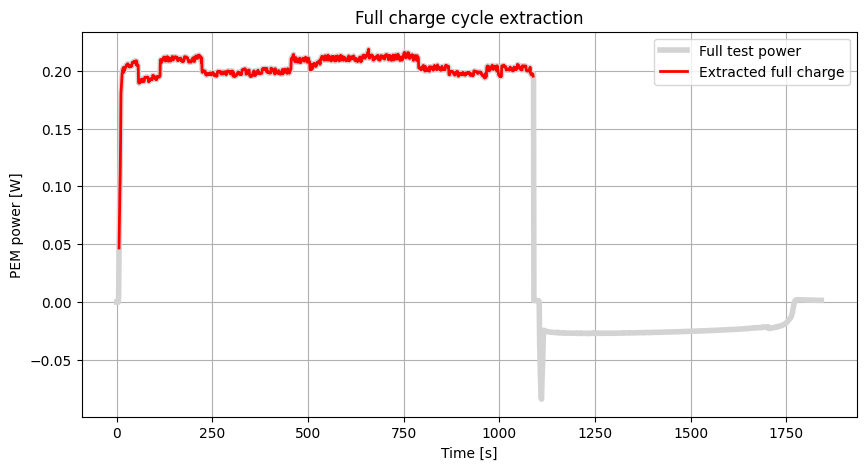

In [5]:
df_full = load_and_correct_file(FULL_CHARGE_FILE)

charge_full = extract_charge_part(
    df_full,
    expected_time_s=None
)

plt.figure(figsize=(10, 5))

plt.plot(
    df_full["time_s"],
    df_full["pem_power_W"],
    color="lightgray",
    linewidth=4,
    label="Full test power"
)

plt.plot(
    charge_full["time_s"],
    charge_full["pem_power_W"],
    color="red",
    linewidth=2,
    label="Extracted full charge"
)

plt.xlabel("Time [s]")
plt.ylabel("PEM power [W]")
plt.title("Full charge cycle extraction")
plt.grid(True)
plt.legend()
plt.show()

In [6]:
I_charge_full_A = abs(charge_full["pem_current_A"])
dt_full_s = charge_full["dt_s"]

Q_charge_full_C = np.sum(
    I_charge_full_A
    * dt_full_s
)

H2_full_theoretical_mL = (
    Q_charge_full_C
    / (z * F)
    * Vm
)

eta_charge_full = (
    FULL_CHARGE_VOLUME_ML
    / H2_full_theoretical_mL
)

H2_CHARGE_FACTOR_ML_PER_C = (
    eta_charge_full
    * Vm
    / (z * F)
)

print(f"Integrated charge from full charge cycle: {Q_charge_full_C:.3f} C")
print(f"Theoretical H2 from full charge cycle: {H2_full_theoretical_mL:.3f} mL")
print(f"Observed H2 from full charge cycle: {FULL_CHARGE_VOLUME_ML:.3f} mL")
print(f"Charge correction factor from full cycle: {eta_charge_full:.3f}")
print(f"Hydrogen charge factor: {H2_CHARGE_FACTOR_ML_PER_C:.8f} mL/C")

print("\nEMS charge equation:")
print(
    f"H2_next_mL = H2_now_mL + "
    f"{H2_CHARGE_FACTOR_ML_PER_C:.8f} * I_charge_A * dt_s"
)

Integrated charge from full charge cycle: 154.024 C
Theoretical H2 from full charge cycle: 19.156 mL
Observed H2 from full charge cycle: 15.600 mL
Charge correction factor from full cycle: 0.814
Hydrogen charge factor: 0.10128313 mL/C

EMS charge equation:
H2_next_mL = H2_now_mL + 0.10128313 * I_charge_A * dt_s


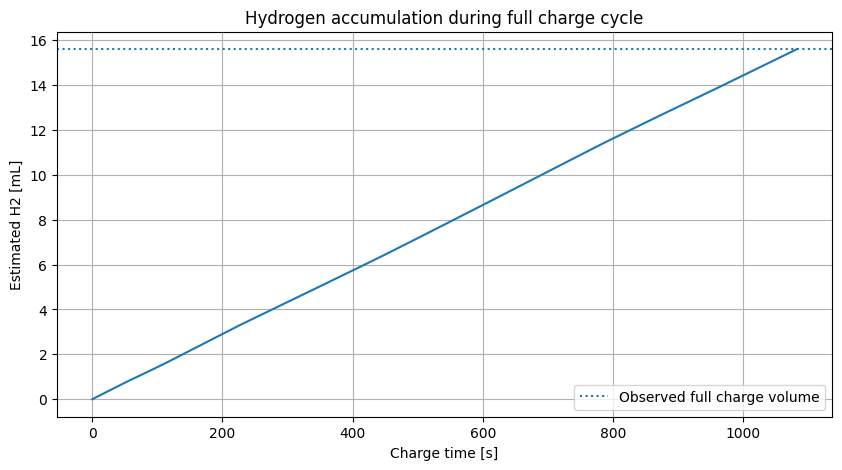

In [7]:
charge_full["dQ_C"] = (
    abs(charge_full["pem_current_A"])
    * charge_full["dt_s"]
)

charge_full["Q_C"] = charge_full["dQ_C"].cumsum()

charge_full["H2_estimated_mL"] = (
    charge_full["Q_C"]
    * H2_CHARGE_FACTOR_ML_PER_C
)

plt.figure(figsize=(10, 5))

plt.plot(
    charge_full["time_charge_s"],
    charge_full["H2_estimated_mL"]
)

plt.axhline(
    FULL_CHARGE_VOLUME_ML,
    linestyle=":",
    label="Observed full charge volume"
)

plt.xlabel("Charge time [s]")
plt.ylabel("Estimated H2 [mL]")
plt.title("Hydrogen accumulation during full charge cycle")
plt.grid(True)
plt.legend()
plt.show()

Validation using the small tests with varying current

In [8]:
validation_results = []

for file_name in charge_test_files:
    expected_current_A, expected_time_s = parse_charge_test_name(file_name)
    
    df = load_and_correct_file(file_name)
    charge = extract_charge_part(
        df,
        expected_time_s=expected_time_s
    )
    
    Q_charge_C = np.sum(
        abs(charge["pem_current_A"])
        * charge["dt_s"]
    )
    
    H2_theoretical_mL = (
        Q_charge_C
        / (z * F)
        * Vm
    )
    
    H2_predicted_mL = (
        Q_charge_C
        * H2_CHARGE_FACTOR_ML_PER_C
    )
    
    validation_results.append({
        "file": file_name,
        "current_A": expected_current_A,
        "time_s": expected_time_s,
        "actual_duration_s": charge["dt_s"].sum(),
        "mean_current_A": charge["pem_current_A"].mean(),
        "Q_charge_C": Q_charge_C,
        "H2_theoretical_mL": H2_theoretical_mL,
        "H2_predicted_mL": H2_predicted_mL
    })

validation_results = pd.DataFrame(validation_results)

validation_results = validation_results.merge(
    readings,
    on=["current_A", "time_s"],
    how="left"
)

validation_results["prediction_error_mL"] = (
    validation_results["H2_predicted_mL"]
    - validation_results["volume_mL"]
)

validation_results["prediction_error_percent"] = (
    100
    * validation_results["prediction_error_mL"]
    / validation_results["volume_mL"]
)

print(validation_results)

                         file  current_A  time_s  actual_duration_s  \
0   discharge_020A_30s_r1.csv        0.2      30               30.0   
1   discharge_020A_60s_r1.csv        0.2      60               60.0   
2  discharge_020A_120s_r1.csv        0.2     120              118.0   
3   discharge_030A_30s_r1.csv        0.3      30               29.0   
4   discharge_030A_60s_r1.csv        0.3      60               60.0   
5  discharge_030A_120s_r1.csv        0.3     120              119.0   
6   discharge_040A_30s_r1.csv        0.4      30               30.0   
7   discharge_040A_60s_r1.csv        0.4      60               60.0   
8  discharge_040A_120s_r1.csv        0.4     120              120.0   

   mean_current_A  Q_charge_C  H2_theoretical_mL  H2_predicted_mL  volume_mL  \
0        0.199971    5.999283           0.746138         0.607626        0.2   
1        0.199995   11.999809           1.492431         1.215378        1.6   
2        0.200300   23.635698           2.939601 

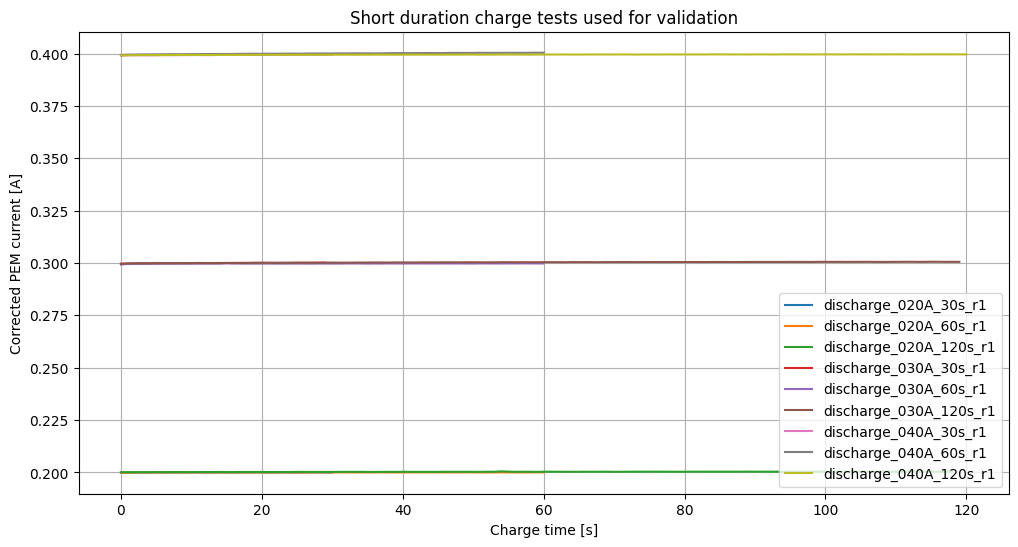

In [9]:
plt.figure(figsize=(12, 6))

for file_name in charge_test_files:
    expected_current_A, expected_time_s = parse_charge_test_name(file_name)
    
    df = load_and_correct_file(file_name)
    charge = extract_charge_part(
        df,
        expected_time_s=expected_time_s
    )
    
    plt.plot(
        charge["time_charge_s"],
        charge["pem_current_A"],
        label=file_name.replace(".csv", "")
    )

plt.xlabel("Charge time [s]")
plt.ylabel("Corrected PEM current [A]")
plt.title("Short duration charge tests used for validation")
plt.grid(True)
plt.legend()
plt.show()

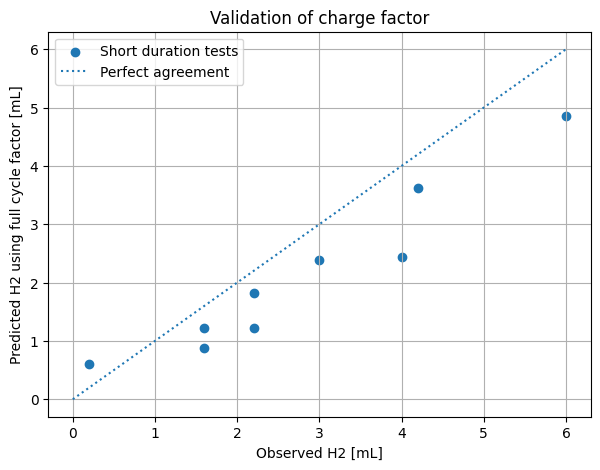

In [10]:
plt.figure(figsize=(7, 5))

plt.scatter(
    validation_results["volume_mL"],
    validation_results["H2_predicted_mL"],
    label="Short duration tests"
)

max_value = max(
    validation_results["volume_mL"].max(),
    validation_results["H2_predicted_mL"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle=":",
    label="Perfect agreement"
)

plt.xlabel("Observed H2 [mL]")
plt.ylabel("Predicted H2 using full cycle factor [mL]")
plt.title("Validation of charge factor")
plt.grid(True)
plt.legend()
plt.show()

In [11]:
charge_current_min = validation_results["current_A"].min()
charge_current_max = validation_results["current_A"].max()

mean_abs_error_mL = validation_results["prediction_error_mL"].abs().mean()
mean_abs_error_percent = validation_results["prediction_error_percent"].abs().mean()

print(f"Final charge factor for EMS: {H2_CHARGE_FACTOR_ML_PER_C:.8f} mL/C")
print(f"Validated charge current range: {charge_current_min:.2f} A to {charge_current_max:.2f} A")
print(f"Mean absolute validation error: {mean_abs_error_mL:.3f} mL")
print(f"Mean absolute validation error: {mean_abs_error_percent:.1f} %")

print("\nUse in EMS:")
print(
    f"H2_next_mL = H2_now_mL + "
    f"{H2_CHARGE_FACTOR_ML_PER_C:.8f} * I_charge_A * dt_s"
)

Final charge factor for EMS: 0.10128313 mL/C
Validated charge current range: 0.20 A to 0.40 A
Mean absolute validation error: 0.753 mL
Mean absolute validation error: 47.5 %

Use in EMS:
H2_next_mL = H2_now_mL + 0.10128313 * I_charge_A * dt_s
